In [126]:
import numpy as np
import scipy as sci
import matplotlib.pyplot as plt

In [127]:
#-----------------------------------------Initial conditions for Figure 8------------------------------------------
M = np.array([1, 1, 1])
G = 1

y0 = np.array([ 0.97000436,     -0.24308753,    0.0,
                -0.97000436,    0.24308753,     0.0,
                0.0,            0.0,            0.0,
                0.4662036850,   0.4323657300,   0.0,
                0.4662036850,   0.4323657300,   0.0,
                -0.93240737,    -0.86473146,    0.0])

In [128]:
def acceleration(x, M):
    N = np.shape(M)[0]
    a = np.zeros((N, 3))
    G = 1
    for i in range(N):
        for j in range(i+1, N):
            x_i, x_j = x[i, :], x[j, :]
            r_ij = x_j - x_i
            r_ij_norm = np.linalg.norm(r_ij)
            
            #Calculate force exerted on i by each j
            a_ij = G*M[i]*M[j]/(r_ij_norm**3 + 1e-14) * (r_ij)
            a[i, :] += a_ij/M[i]
            a[j, :] -= a_ij/M[j]
    return a

In [129]:
def potential(x, M):
    N = np.shape(M)[0]
    U = 0
    for i in range(N):
        for j in range(i+1, N):
            x_i, x_j = x[i, :], x[j, :]
            r_ij = x_j - x_i
            r_ij_norm = np.linalg.norm(r_ij)
            
            #Calculating potentials
            U_ij = -G*M[i]*M[j]/(r_ij_norm)
            U += U_ij 
    return U

In [130]:
def f(t, y, M):
    N = np.shape(M)[0]
    x = y[0:3*N].reshape(3, 3)
    v = y[3*N:]

    dx_dt = v
    dv_dt = acceleration(x, M).flatten()
    return np.concatenate((dx_dt, dv_dt))

In [157]:
time = (0, 50)
dt = 0.001
timesteps = int(50/dt)

time_eval = np.arange(0, 50, dt)
solution = sci.integrate.solve_ivp(f, time, y0, 'RK45', time_eval, args = (M,))

In [158]:
N = np.shape(M)[0]

positions = solution.y[:3*3].reshape(3, 3, -1)
velocities = solution.y[3*3:].reshape(3, 3, -1)

T = np.zeros(timesteps)
U = np.zeros(timesteps)
P = np.zeros((3, timesteps))
L = np.zeros((3, timesteps))

for i in range(timesteps):
    T[i] = np.sum(0.5*M*np.linalg.norm(velocities[:, :, i], axis = 1)**2)
    U[i] = potential(positions[:, :, i], M)
    for j in range(N):
        P_j = M[j] * velocities[j, :, i]
        L_j = np.cross(positions[j, :, i], P_j)
        P[:, i] += P_j
        L[:, i] += L_j

E = T + U
E_error = 100*(E-E[0])/E[0]
P_error = 100*np.linalg.norm((P-P[:, 0][:, None]), axis = 0)/np.linalg.norm((M[0] * velocities[0, :, i]))
L_error = 100*np.linalg.norm((L-L[:, 0][:, None]), axis = 0)/np.linalg.norm(np.cross(positions[0, :, i], M[0] * velocities[0, :, i]))


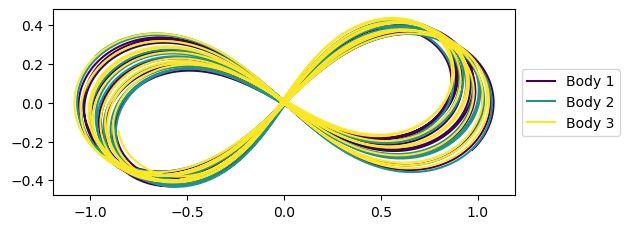

Text(0.5, 1.0, 'Angular Momentum Error')

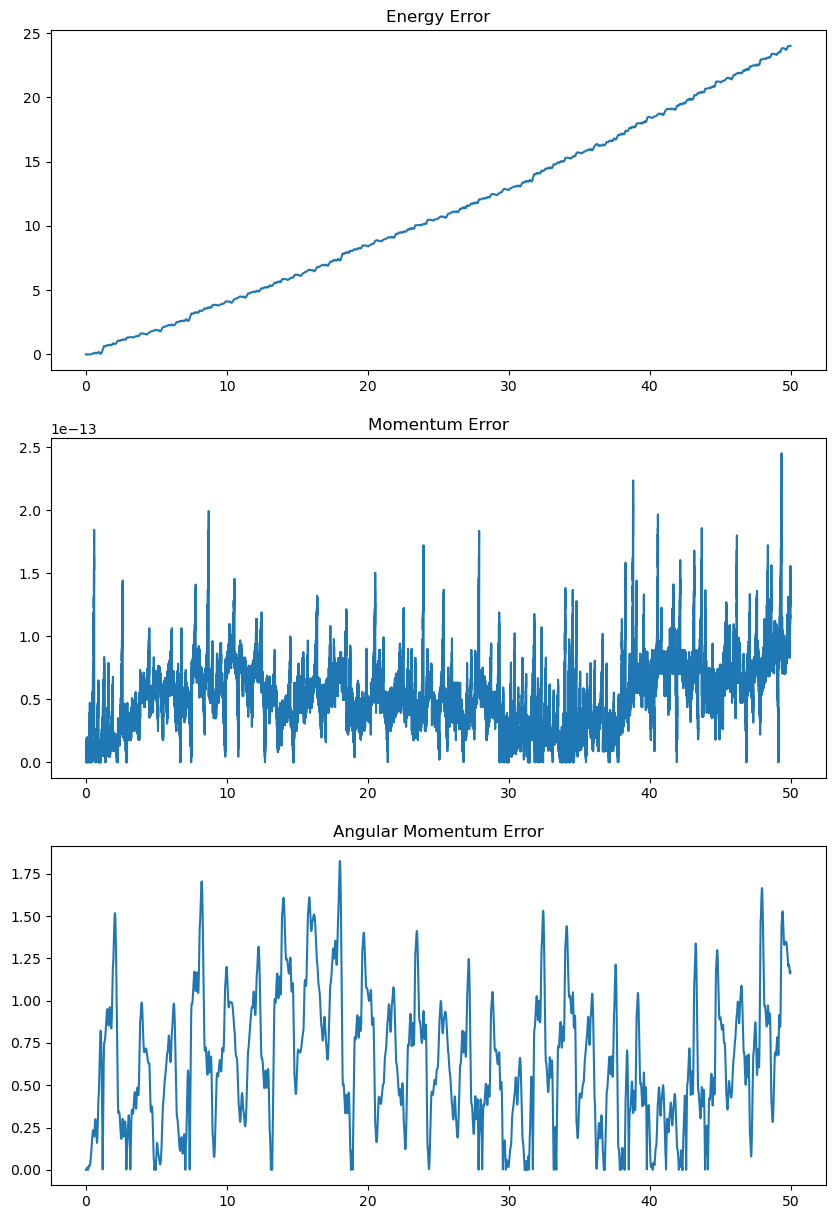

In [159]:
colors = plt.cm.viridis(np.linspace(0, 1, N))
fig1, axa = plt.subplots()
for i in range(3):
    axa.plot(positions[i, 0], positions[i, 1], color = colors[i], label=f'Body {i+1}')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5)) 
axa.set_aspect('equal')
plt.tight_layout()
plt.show()

fig2, axb = plt.subplots(3, 1, figsize = (10, 15))
axb[0].plot(time_eval, E_error)
axb[1].plot(time_eval, P_error)
axb[2].plot(time_eval, L_error)
axb[0].set_title("Energy Error")
axb[1].set_title("Momentum Error")
axb[2].set_title("Angular Momentum Error")